### Import libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [2]:
import numpy as np

### Extract data from folders

In [3]:
train_dataset_path = "pneumonia_detection/train"

train_img_path = []
train_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(train_dataset_path, class_name)

  for file in os.listdir(class_dir):
    train_img_path.append(os.path.join(class_dir, file))
    train_labels.append(label)

In [4]:
val_dataset_path = "pneumonia_detection/val"

val_img_path = []
val_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(val_dataset_path, class_name)

  for file in os.listdir(class_dir):
    val_img_path.append(os.path.join(class_dir, file))
    val_labels.append(label)

In [5]:
test_dataset_path = "pneumonia_detection/test"

test_img_path = []
test_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(test_dataset_path, class_name)

  for file in os.listdir(class_dir):
    test_img_path.append(os.path.join(class_dir, file))
    test_labels.append(label)

### Analyse the train data - class imbalance, etc

In [6]:
count = np.bincount(train_labels)
print(f"Class distribution in training data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(val_labels)
print(f"Class distribution in validation data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(test_labels)
print(f"Class distribution in test data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

Class distribution in training data:
Class NORMAL: 1236
Class PNEUMONIA: 3770
Class distribution in validation data:
Class NORMAL: 113
Class PNEUMONIA: 113
Class distribution in test data:
Class NORMAL: 234
Class PNEUMONIA: 390


### Creating dataset pipeline for train, test and validation datasets

In [7]:
train_data = tf.data.Dataset.from_tensor_slices((train_img_path, train_labels))
val_data = tf.data.Dataset.from_tensor_slices((val_img_path,val_labels))
test_data = tf.data.Dataset.from_tensor_slices((test_img_path, test_labels))

In [8]:
def preprocessing(path, label):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, ((224,224)))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image, label


In [9]:
train_data = train_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(len(train_labels))
train_data = train_data.batch(32)
train_data = train_data.prefetch(tf.data.AUTOTUNE)

val_data = val_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_data.batch(32)
val_data = val_data.prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.batch(32)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

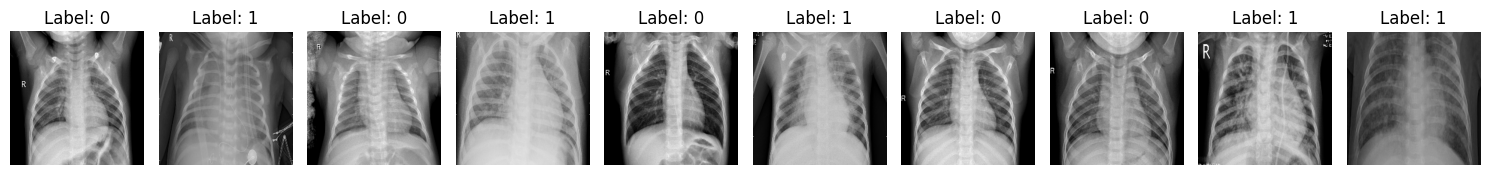

In [10]:
for images, labels in train_data.take(1):
  plt.figure(figsize=(15, 10))
  for i in range(10):
    display_image = (images[i] + 1)/2
    plt.subplot(1, 10, i + 1)
    plt.imshow(display_image)
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

### Loading MobileNetV2 and adding a classification head

In [11]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(224,224,3), weights="imagenet", include_top=False)

In [12]:
base_model.trainable = False

In [13]:
base_model.output_shape

(None, 7, 7, 1280)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

In [15]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Based on the output obtained, use the formula n1w1 = n2w2 to assign weights to each class. Initially assume weight for pneumonia class as 1 and calculate n1 (weight for normal class) using the formula w1 = n2/n1 where n2 is number of pneumonia samples in training data and n1 is number of normal samples in training data. Based on this calculation, I have assigned the class weights as follows -> w1 = 3; w2 = 1

### Training the model

In [16]:
class_weight = {
    0: 3.0,
    1: 1.0
}

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.05,
    patience = 3,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 20,
    callbacks = early_stopping,
    class_weight = class_weight
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 155ms/step - accuracy: 0.9221 - loss: 0.2789 - pr_auc: 0.9929 - precision: 0.9726 - recall: 0.9225 - roc_auc: 0.9785 - val_accuracy: 0.9779 - val_loss: 0.0804 - val_pr_auc: 0.9974 - val_precision: 0.9909 - val_recall: 0.9646 - val_roc_auc: 0.9975
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.9698 - loss: 0.1281 - pr_auc: 0.9984 - precision: 0.9921 - recall: 0.9676 - roc_auc: 0.9950 - val_accuracy: 0.9867 - val_loss: 0.0571 - val_pr_auc: 0.9979 - val_precision: 0.9911 - val_recall: 0.9823 - val_roc_auc: 0.9980
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.9710 - loss: 0.1048 - pr_auc: 0.9989 - precision: 0.9932 - recall: 0.9682 - roc_auc: 0.9963 - val_accuracy: 0.9779 - val_loss: 0.0588 - val_pr_auc: 0.9980 - val_precision: 0.9909 - val_recall: 0.9646 - val_roc_auc: 0.9980
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 183ms/step - accuracy: 0.9766 - loss: 0.0874 - pr_auc: 0.9992 - precision: 0.9940 -

### Unfreezing last 20% of layers

In [20]:
n= int(int(len(base_model.layers)) * 0.2)

In [21]:
for layer in base_model.layers[:-n]:
    layer.trainable = False

for layer in base_model.layers[-n:]:
    layer.trainable = True

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

In [23]:
early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.05,
    patience = 3,
    restore_best_weights=True
)

In [24]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 20,
    callbacks = early_stopping_2,
    class_weight = class_weight
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 208ms/step - accuracy: 0.8809 - loss: 0.7213 - pr_auc: 0.9848 - precision_1: 0.8732 - recall_1: 0.9849 - roc_auc: 0.9607 - val_accuracy: 0.9690 - val_loss: 0.0797 - val_pr_auc: 0.9971 - val_precision_1: 0.9818 - val_recall_1: 0.9558 - val_roc_auc: 0.9971
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 214ms/step - accuracy: 0.9283 - loss: 0.4045 - pr_auc: 0.9918 - precision_1: 0.9347 - recall_1: 0.9727 - roc_auc: 0.9761 - val_accuracy: 0.9602 - val_loss: 0.0837 - val_pr_auc: 0.9977 - val_precision_1: 0.9815 - val_recall_1: 0.9381 - val_roc_auc: 0.9977
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 221ms/step - accuracy: 0.9403 - loss: 0.2900 - pr_auc: 0.9941 - precision_1: 0.9614 - recall_1: 0.9592 - roc_auc: 0.9819 - val_accuracy: 0.9602 - val_loss: 0.0903 - val_pr_auc: 0.9976 - val_precision_1: 0.9815 - val_recall_1: 0.9381 - val_roc_auc: 0.9977
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 264ms/step - accuracy: 0.9441 - loss: 0.2429 - pr_auc: 0.99

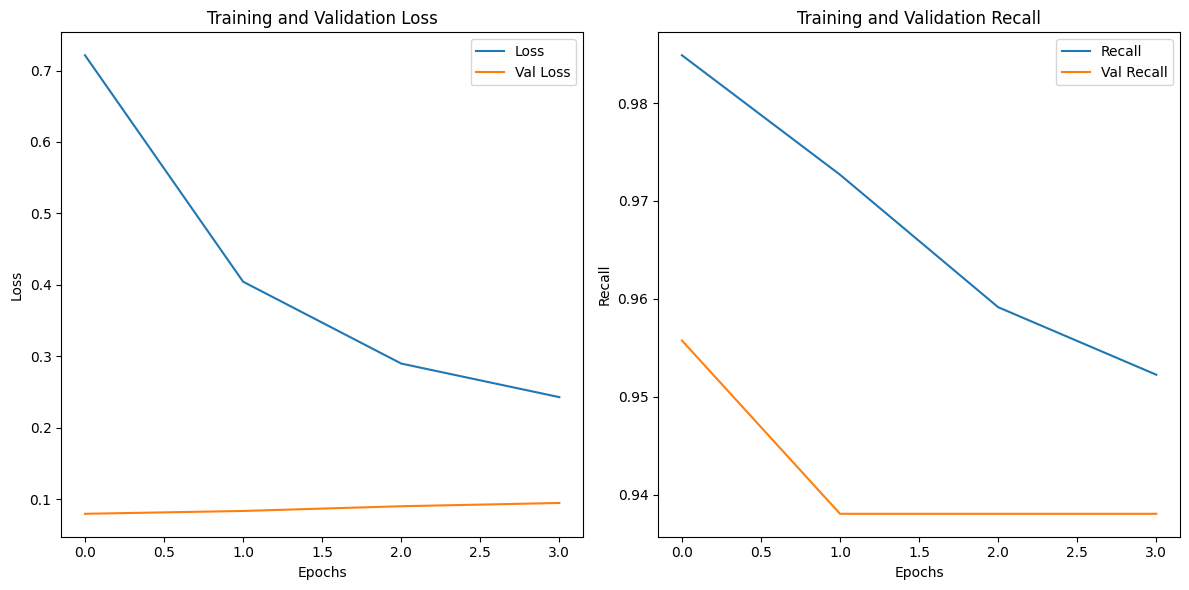

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # Subplot for Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Loss", "Val Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2) # Subplot for Recall
plt.plot(history.history["recall_1"])
plt.plot(history.history["val_recall_1"])
plt.legend(["Recall", "Val Recall"])
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("Training and Validation Recall")

plt.tight_layout()
plt.show()

### Evaluating the model on the test set

In [27]:
results = model.evaluate(test_data, return_dict = True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8862 - loss: 0.2913 - pr_auc: 0.9763 - precision_1: 0.8600 - recall_1: 0.9769 - roc_auc: 0.9638


In [28]:
results

{'accuracy': 0.8862179517745972,
 'loss': 0.2913104295730591,
 'pr_auc': 0.9763402342796326,
 'precision_1': 0.8600451350212097,
 'recall_1': 0.9769230484962463,
 'roc_auc': 0.9637848138809204}

In [31]:
print(f"Results")
print(f"Loss:{results["loss"]:.2f}")
print(f"Accuracy:{results["accuracy"]:.2f}")
print(f"Precision:{results["precision_1"]:.2f}")
print(f"Recall:{results["recall_1"]:.2f}")
print(f"AUC-ROC:{results["roc_auc"]:.2f}")
print(f"PR-AUC:{results["pr_auc"]:.2f}")

Results
Loss:0.29
Accuracy:0.89
Precision:0.86
Recall:0.98
AUC-ROC:0.96
PR-AUC:0.98


In [32]:
model.save("mobilenet_finetuned.keras")

In [33]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, classification_report

y_preds = model.predict(test_data)

y_preds = (y_preds > 0.5).astype(int).flatten()

# for getting y_true

y_true = []

for image, label in test_data:
  y_true.extend(label.numpy())

y_true = np.array(y_true)

cm = confusion_matrix(y_true, y_preds)
print(cm)

print(classification_report(y_true, y_preds))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step
[[172  62]
 [  9 381]]
              precision    recall  f1-score   support

           0       0.95      0.74      0.83       234
           1       0.86      0.98      0.91       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



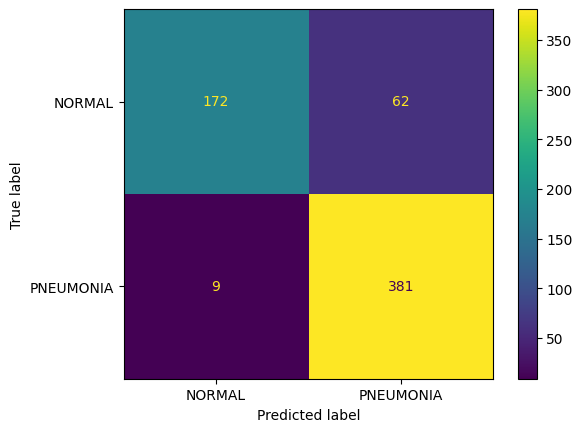

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(cm, display_labels=["NORMAL","PNEUMONIA"])

display.plot()